<!-- notebook:description -->
# Notebook: RQ5 — Completeness Impact

**Rôle**: mesurer l'impact de la complétude de la documentation sur les résultats.

**Objectif**: analyser corrélations/variations de métriques en fonction de la complétude (RQ5).

*Notebook basé sur données réelles (dernier rapport JSON RQ5). Pas de simulation.*

## Load latest RQ5 report

<!-- explain-cell -->
### Étape 1
Cette cellule exécute une partie de l'analyse (imports / chargement de données / calculs / visualisations / export)


In [1]:
# --- cell-doc ---
# But: exécuter un bloc de l'analyse sans modifier la logique.
# Entrées: variables définies par les cellules précédentes.
# Sorties: variables/figures/fichiers produits par ce bloc.

import json
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)

REPORT_DIR = Path('../results/rq5')
report_files = sorted(REPORT_DIR.glob('rq5_report_*.json'), key=lambda p: p.stat().st_mtime, reverse=True)
if not report_files:
    raise FileNotFoundError(
        f'No RQ5 report found in {REPORT_DIR.resolve()}. Run experiments/rq5_completeness_impact.py to generate rq5_report_*.json'
    )
REPORT_PATH = report_files[0]
print('Using report:', REPORT_PATH)

report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))
report.keys()


Using report: ../results/rq5/rq5_report_httpbin_testing_api_rq5_20251213_041306.json


dict_keys(['experiment_id', 'config', 'started_at', 'completed_at', 'model_results', 'overall_findings', 'recommendations'])

## Level results (model × completeness)

<!-- explain-cell -->
### Étape 2
Cette cellule exécute une partie de l'analyse (imports / chargement de données / calculs / visualisations / export)


In [2]:
# --- cell-doc ---
# But: exécuter un bloc de l'analyse sans modifier la logique.
# Entrées: variables définies par les cellules précédentes.
# Sorties: variables/figures/fichiers produits par ce bloc.

rows = []
for mr in (report.get('model_results') or []):
    llm = mr.get('llm_model')
    corr = (mr.get('correlations') or {}).get('completeness_quality')
    robust = mr.get('robustness_score')
    degr = (mr.get('degradation_rates') or {}).get('quality_per_10pct')
    thresh = (mr.get('thresholds') or {}).get('min_for_quality_80')

    for lr in (mr.get('level_results') or []):
        rows.append({
            'llm_model': llm,
            'completeness_level': lr.get('completeness_level'),
            'completeness_pct': (lr.get('completeness_level') or 0) * 100,
            'overall_quality': lr.get('overall_quality'),
            'coherence_score': (lr.get('consistency_metrics') or {}).get('coherence_score'),
            'avg_inconsistency_count': (lr.get('consistency_metrics') or {}).get('avg_inconsistency_count'),
            'oracle_f1': (lr.get('oracle_metrics') or {}).get('f1'),
            'code_overall': (lr.get('code_quality_metrics') or {}).get('overall'),
            'endpoint_count': lr.get('endpoint_count'),
            'corr_completeness_quality': corr,
            'robustness_score': robust,
            'quality_degradation_per_10pct': degr,
            'min_completeness_for_quality_80': thresh,
        })

level_df = pd.DataFrame(rows)
level_df.sort_values(['llm_model', 'completeness_level'], ascending=[True, False]).head(20)


,llm_model,completeness_level,completeness_pct,overall_quality,coherence_score,avg_inconsistency_count,oracle_f1,code_overall,endpoint_count,corr_completeness_quality,robustness_score,quality_degradation_per_10pct,min_completeness_for_quality_80
0,llama32,1.0,100.0,0.682274,0.7,2.5,0.453896,0.79875,8,0.0,0.0,0.0,0.0


## Visualizations

<!-- explain-cell -->
### Étape 3
Cette cellule exécute une partie de l'analyse (imports / chargement de données / calculs / visualisations / export)


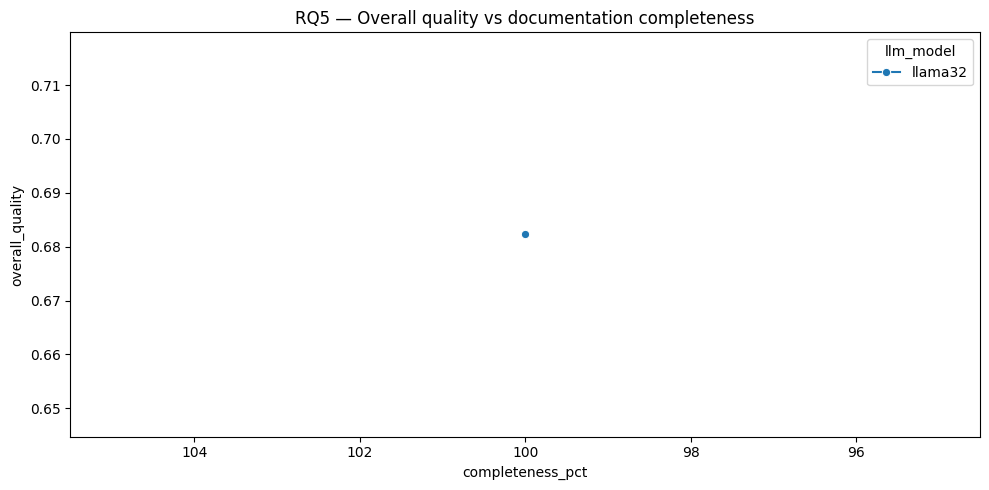

,llm_model,corr_completeness_quality,robustness_score,quality_degradation_per_10pct,min_completeness_for_quality_80
0,llama32,0.0,0.0,0.0,0.0


In [3]:
# --- cell-doc ---
# But: exécuter un bloc de l'analyse sans modifier la logique.
# Entrées: variables définies par les cellules précédentes.
# Sorties: variables/figures/fichiers produits par ce bloc.

if level_df.empty:
    raise ValueError('No model_results/level_results in report.')

plt.figure(figsize=(10, 5))
sns.lineplot(data=level_df, x='completeness_pct', y='overall_quality', hue='llm_model', marker='o')
plt.title('RQ5 — Overall quality vs documentation completeness')
plt.gca().invert_xaxis()  # show 100% -> low completeness left-to-right
plt.tight_layout()
plt.show()

corr_df = level_df[['llm_model', 'corr_completeness_quality', 'robustness_score', 'quality_degradation_per_10pct', 'min_completeness_for_quality_80']].drop_duplicates()
display(corr_df.sort_values('corr_completeness_quality', ascending=False))


## Export

<!-- explain-cell -->
### Étape 4
Cette cellule exécute une partie de l'analyse (imports / chargement de données / calculs / visualisations / export)


In [4]:
# --- cell-doc ---
# But: exécuter un bloc de l'analyse sans modifier la logique.
# Entrées: variables définies par les cellules précédentes.
# Sorties: variables/figures/fichiers produits par ce bloc.

OUT_DIR = Path('./outputs/rq5')
OUT_DIR.mkdir(parents=True, exist_ok=True)

level_df.to_csv(OUT_DIR / 'rq5_level_results.csv', index=False)

summary = {
    'report_path': str(REPORT_PATH),
    'experiment_id': report.get('experiment_id'),
    'overall_findings': report.get('overall_findings'),
    'recommendations': report.get('recommendations'),
}
(OUT_DIR / 'rq5_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('Wrote:', OUT_DIR)


Wrote: outputs/rq5
